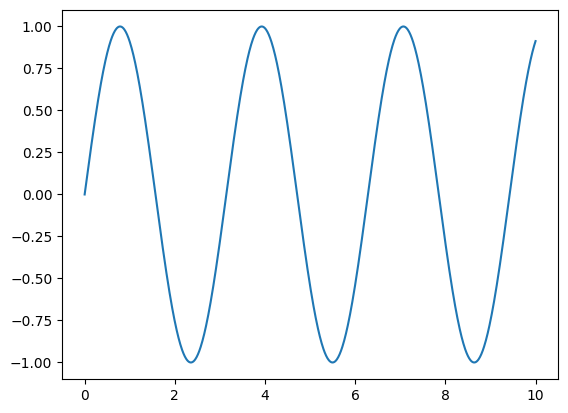

In [ ]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

x_jnp = jnp.linspace(0, 10, 1000)
y_jnp = 2 * jnp.sin(x_jnp) * jnp.cos(x_jnp)
plt.plot(x_jnp, y_jnp)

In [2]:
import numpy as np
import jax.numpy as jnp

x_np = np.linspace(0, 10, 1000)
x_jnp = jnp.linspace(0, 10, 1000)

In [3]:
type(x_np)

numpy.ndarray

In [4]:
type(x_jnp)

jaxlib._jax.ArrayImpl

In [5]:
# NumPy: mutable arrays
x = np.arange(10)
x[0] = 10
print(x)

[10  1  2  3  4  5  6  7  8  9]


In [6]:
%xmode minimal

Exception reporting mode: Minimal


In [7]:
# JAX: immutable arrays
x = jnp.arange(10)
x[0] = 10

TypeError: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html

In [ ]:
import jax
import jax.numpy as jnp

x = jnp.arange(5)
isinstance(x, jax.Array)


True

In [ ]:
x.devices()

{CpuDevice(id=0)}

In [ ]:
x.sharding

SingleDeviceSharding(device=CpuDevice(id=0), memory_kind=device)

In [ ]:
import jax.numpy as jnp
dir(jnp)

['ComplexWarning',
 '__array_api_version__',
 '__array_namespace_info__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__getattr__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_deprecations',
 'abs',
 'absolute',
 'acos',
 'acosh',
 'add',
 'all',
 'allclose',
 'amax',
 'amin',
 'angle',
 'any',
 'append',
 'apply_along_axis',
 'apply_over_axes',
 'arange',
 'arccos',
 'arccosh',
 'arcsin',
 'arcsinh',
 'arctan',
 'arctan2',
 'arctanh',
 'argmax',
 'argmin',
 'argpartition',
 'argsort',
 'argwhere',
 'around',
 'array',
 'array_equal',
 'array_equiv',
 'array_repr',
 'array_split',
 'array_str',
 'asarray',
 'asin',
 'asinh',
 'astype',
 'atan',
 'atan2',
 'atanh',
 'atleast_1d',
 'atleast_2d',
 'atleast_3d',
 'average',
 'bartlett',
 'bfloat16',
 'bincount',
 'bitwise_and',
 'bitwise_count',
 'bitwise_invert',
 'bitwise_left_shift',
 'bitwise_not',
 'bitwise_or',
 'bitwise_right_shift',
 'bitwise_xor',
 'blackman',
 'block',
 'bool',
 'bool_'

In [ ]:
x=jnp.array([1,1])

In [ ]:
x

Array([1, 1], dtype=int32)

In [ ]:
x[0]=10

TypeError: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html

In [ ]:
jnp.asarray([1,2])

Array([1, 2], dtype=int32)

the difference is that asarray avoids unnessasary copies of same data, it only creates new data when it has to cause it cannot directly conver it for example if we pass a np array to this function it has to conver the values to float32 to convert as 64 bit types are disabled by default, but it will not create a copy when we do pass it a array already consisting of float32 values (these are also present in numpy but numpy arrays are mutable i.e. they can be chnaged after initialization)

In [ ]:
x = jnp.arange(12).reshape(3, 4)
x[1, 2]

Array(6, dtype=int32)

since, the arrays are immutable in jax and if we slice this array the slice returns a new array entirely, we can even do something like dynamic slicing instead of static slicing even in jit (we'll look into it in future discussion)

# Compilation Pipiline

Python/JAX code
   |
   v
Tracing / JAXPR
   |
   v
StableHLO
   |
   v
XLA compiler
   |
   v
Device executable
   |
   v
CPU / GPU / TPU

Python/JAX code: your original function, often wrapped with jax.jit

Tracing / JAXPR: JAXPR records the computation instead of running it eagerly.jaxpr records JAX primitives like add, sin, dot_general, or reduce_sum, along with the data flow between them in a symbolic manner on which jax's compiler can run and do transformations upon

StableHLO: the portable intermediate representation JAX lowers into

XLA compiler: optimizes and compiles the StableHLO program

Device executable: backend-specific binary executable for the target hardware

CPU / GPU / TPU: where the compiled code actually runs

In [ ]:
import jax
import jax.numpy as jnp

def f(x):
    return x * 2 + 1

print(jax.make_jaxpr(f)(3.0))

{ lambda ; a:f32[]. let
    b:f32[] = mul a 2.0:f32[]
    c:f32[] = add b 1.0:f32[]
  in (c,) }


jaxpr is a first order language which helps break the higher level jax code into lower level operations

all of these mul and add here are the primitive operations of jax into which the function is broken all these primitives can be seen in jax.lax which basically the stricter/lower-level version of jax which is in contrast to the jax.numpy version which is a higher level wrapper over jax.lax (all the function defined over there are broken down into the function of jax.lax)

In [ ]:
import jax.numpy as jnp
jnp.add(1, 1.0)

Array(2., dtype=float32, weak_type=True)

In [ ]:
from jax import lax
lax.add(1, 1.0)

TypeError: lax.add requires arguments to have the same dtypes, got int32, float32. (Tip: jnp.add is a similar function that does automatic type promotion on inputs).

this shows that in jnp we can directly add mixed types but in lax which is the lower level version we cannot add the 2 without them being the same type

In [ ]:
def g(x):
    y = jnp.reshape(x, (2, 2))
    return jnp.sum(y, axis=0)

print(jax.make_jaxpr(g)(jnp.arange(4.0)))

{ lambda ; a:f32[4]. let
    b:f32[2,2] = reshape[dimensions=None new_sizes=(2, 2) sharding=None] a
    c:f32[2] = reduce_sum[axes=(0,) out_sharding=None] b
  in (c,) }


In [ ]:
import jax
import jax.numpy as jnp

global_list = []

def log2(x):
  global_list.append(x)
  ln_x = jnp.log(x)
  ln_2 = jnp.log(2.0)
  return ln_x / ln_2

print(jax.make_jaxpr(log2)(3.0))

{ lambda ; a:f32[]. let
    b:f32[] = log a
    c:f32[] = log 2.0:f32[]
    d:f32[] = div b c
  in (d,) }


also there is this thing called tracer which helps jax turn into jaxpr it is a placeholder value which is treated as input to the function so we can track/trace the operations occuring in above case x is intialized as tracer and when jaxpr is made there is no use of tracer anymore so the tracer disappers 

what we do is give each argument of the function it's own tracer object and then let each argument observe what operations were done onto them this has several implications like if we use conditional in a function then jaxpr only denotes the path we took instead of the whole if-else statement

In [ ]:
def log2_if_rank_2(x):
  if x.ndim == 2:
    ln_x = jnp.log(x)
    ln_2 = jnp.log(2.0)
    return ln_x / ln_2
  else:
    return x

print(jax.make_jaxpr(log2_if_rank_2)(jax.numpy.array([1, 2, 3])))

{ lambda ; a:i32[3]. let  in (a,) }


In [ ]:
def log2_with_print(x):
  print("printed x:", x)
  ln_x = jnp.log(x)
  ln_2 = jnp.log(2.0)
  return ln_x / ln_2

print(jax.make_jaxpr(log2_with_print)(3.))

printed x: JitTracer(~float32[])
{ lambda ; a:f32[]. let
    b:f32[] = log a
    c:f32[] = log 2.0:f32[]
    d:f32[] = div b c
  in (d,) }


this can work only on pure functions and print function is not pure as the text on screen is just a sideeffect 

# Debugging: Impurity

if we want debug printing, use jax.debug.print()

To express general side-effects at the cost of performance, see jax.experimental.io_callback(). To check for tracer leaks at the cost of performance, use with jax.check_tracer_leaks()

# Just in Time Compilation

In [ ]:
import jax
import jax.numpy as jnp

def selu(x, alpha=1.67, lambda_=1.05):
  return lambda_ * jnp.where(x > 0, x, alpha * jnp.exp(x) - alpha)

x = jnp.arange(1000000)
%timeit selu(x).block_until_ready()

7.08 ms ± 765 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
selu_jit = jax.jit(selu)

# Pre-compile the function before timing...
selu_jit(x).block_until_ready()

%timeit selu_jit(x).block_until_ready()

1.67 ms ± 28.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


We called selu_jit once on x. This is where JAX does its tracing – it needs to have some inputs to wrap in tracers, after all. The jaxpr is then compiled using XLA into very efficient code optimized for your GPU or TPU. Finally, the compiled code is executed to satisfy the call. Subsequent calls to selu_jit will use the compiled code directly, skipping the python implementation entirely. (If we didn’t include the warm-up call separately, everything would still work, but then the compilation time would be included in the benchmark. It would still be faster, because we run many loops in the benchmark, but it wouldn’t be a fair comparison.)

In [ ]:
# Condition on value of x.

def f(x):
  if x > 0:
    return x
  else:
    return 2 * x

jax.jit(f)(10)  # Raises an error

TracerBoolConversionError: Attempted boolean conversion of traced array with shape bool[].
The error occurred while tracing the function f at C:\Users\btech\AppData\Local\Temp\ipykernel_38284\2956679937.py:3 for jit. This concrete value was not available in Python because it depends on the value of the argument x.
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerBoolConversionError

In [ ]:
# While loop conditioned on x and n.

def g(x, n):
  i = 0
  while i < n:
    i += 1
  return x + i

jax.jit(g)(10, 20)  # Raises an error

TracerBoolConversionError: Attempted boolean conversion of traced array with shape bool[].
The error occurred while tracing the function g at C:\Users\btech\AppData\Local\Temp\ipykernel_38284\722961019.py:3 for jit. This concrete value was not available in Python because it depends on the value of the argument n.
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerBoolConversionError

problem with both of them is that we tried to change the flow of traced programs using the value of the runtime variables (that means that we are trying to make program traces and we need the value of varibles to control what trace would look like in the end of the jaxpr conversion)

solution: one way is to avoid having conditional on value entirely
another way is to use flow control operator defiened in lax package jax.lax.cond() 

even then it is not practical sometimes to do that. so, we can also compile the part of function using jit whihc is computationally heavy 

In [ ]:
# While loop conditioned on x and n with a jitted body.

@jax.jit
def loop_body(prev_i):
  return prev_i + 1

def g_inner_jitted(x, n):
  i = 0
  while i < n:
    i = loop_body(i)
  return x + i

g_inner_jitted(10, 20)

Array(30, dtype=int32, weak_type=True)

# Marking arguments as static

If we really need to JIT-compile a function that has a condition on the value of an input, we can tell JAX to help itself to a less abstract tracer for a particular input by specifying static_argnums or static_argnames. jax recompiles the code for every new value it receives and hence it is a good strategy only when the function recives a narrow set of values for that particular input

In [ ]:
import jax
a=1

In [21]:
def f(a):
    return a + 1
def g(a, n):
    return a + n - 1

In [25]:
f_jit_correct = jax.jit(f, static_argnums=0)
print(f_jit_correct(10))

11


In [26]:
import jax
import jax.numpy as jnp

def f(x, n):
    return x + n

f_jit = jax.jit(f, static_argnums=1)

print(f_jit(jnp.array([1, 2, 3]), 10))

[11 12 13]


argnum is basically telling the argument number which has to be treated as the compile time variable

In [23]:
g_jit_correct = jax.jit(g, static_argnames=['n'])
print(g_jit_correct(10, 20))

29


In [ ]:
@jax.jit(static_argnames=['n'])
def g_jit_decorated(x, n):
  i = 0
  while i < n:
    i += 1
  return x + i

print(g_jit_decorated(10, 20))

In [ ]:
@jax.jit(static_argnums=1)
def g_jit_decorated(x, n):
  i = 0
  while i < n:
    i += 1
  return x + i

print(g_jit_decorated(10, 20))

# Automatic Vectorization

In [44]:
import jax
import jax.numpy as jnp

x = jnp.arange(5)
w = jnp.array([2., 3., 4.])

def convolve(x, w):
  output = []
  for i in range(1, len(x)-1):
    output.append(jnp.dot(x[i-1:i+2], w))
  return jnp.array(output)

convolve(x, w)

Array([11., 20., 29.], dtype=float32)

In [48]:
batch_size = 2
xs = jnp.stack([x] * batch_size)          # shape: (2, 5)
ws = jnp.broadcast_to(w, (batch_size, 3))  # shape: (2, 3)

auto_batch_convolve = jax.vmap(convolve)
print(auto_batch_convolve(xs, ws))

[[11. 20. 29.]
 [11. 20. 29.]]


In [49]:
auto_batch_convolve_v2 = jax.vmap(convolve, in_axes=1, out_axes=1)

xst = jnp.transpose(xs)
wst = jnp.transpose(ws)

auto_batch_convolve_v2(xst, wst)

Array([[11., 11.],
       [20., 20.],
       [29., 29.]], dtype=float32)

Vectorization of a function usually means rewriting it so it can operate on arrays or batches of values at once instead of handling one scalar value at a time.

so, to vetorize a function we can directly pass it to vmap and it would preplare the function for a batch instead of just a stacalr input.

In [52]:
auto_batch_convolve_v2 = jax.vmap(convolve, in_axes=1, out_axes=1)

xst = jnp.transpose(xs)
wst = jnp.transpose(ws)

auto_batch_convolve_v2(xst, wst)

Array([[11., 11.],
       [20., 20.],
       [29., 29.]], dtype=float32)

In [53]:
batch_convolve_v3 = jax.vmap(convolve, in_axes=[0, None])

batch_convolve_v3(xs, w)

Array([[11., 20., 29.],
       [11., 20., 29.]], dtype=float32)

In [54]:
jitted_batch_convolve = jax.jit(auto_batch_convolve)
jitted_batch_convolve(xs, ws)

Array([[11., 20., 29.],
       [11., 20., 29.]], dtype=float32)

we can even jit the vmaped functions

# Automatic Differentiation

In [3]:
from jax import grad
import jax.numpy as jnp
grad_tanh = grad(jnp.tanh)
print(grad_tanh(2.0))

0.070650816


In [4]:
#higher order differentials
print(grad(grad(jnp.tanh))(2.0))
print(grad(grad(grad(jnp.tanh)))(2.0))

-0.13621868
0.25265405


# Linear Regression 

## Dataset generation

In [26]:
import jax
import jax.numpy as jnp

key = jax.random.PRNGKey(42)
n_samples = 1000
x = jax.random.uniform(key, (n_samples, 1), minval=-5, maxval=5)
true_m = 3.5
true_b = 2.0

noise = 0.5 * jax.random.normal(key, (n_samples, 1))

y = true_m * x + true_b + noise

In [27]:
#y=mx+b
m,b=0.0,0.0
param=jnp.array([m, b])
def predict(param, x):
    return param[0]*x+param[1]
def loss(param, x, y):
    y_pred = predict(param, x)
    return jnp.mean((y - y_pred) ** 2)
@jax.jit
def train_step(x, y, param, alpha=0.01, tolerance=0.1):
    alpha_grad=(jax.grad(loss)(param, x, y))*alpha
    return param-alpha_grad

In [28]:
train_step(x,y,param)

Array([0.616871  , 0.05091612], dtype=float32)

we can either just use this jit compiled command and loop over it or we need a jit's version of loops i will get back to it in future when i do learn how to loop 

# Pytrees

In [30]:
import jax
import jax.numpy as jnp

example_trees = [
    [1, 'a', object()],
    (1, (2, 3), ()),
    [1, {'k1': 2, 'k2': (3, 4)}, 5],
    {'a': 2, 'b': (2, 3)},
    jnp.array([1, 2, 3]),
]

# Print how many leaves the pytrees have.
for pytree in example_trees:
  # This `jax.tree.leaves()` method extracts the flattened leaves from the pytrees.
  leaves = jax.tree.leaves(pytree)
  print(f"{repr(pytree):<45} has {len(leaves)} leaves: {leaves}")

[1, 'a', <object object at 0x000001A7C0C6B800>] has 3 leaves: [1, 'a', <object object at 0x000001A7C0C6B800>]
(1, (2, 3), ())                               has 3 leaves: [1, 2, 3]
[1, {'k1': 2, 'k2': (3, 4)}, 5]               has 5 leaves: [1, 2, 3, 4, 5]
{'a': 2, 'b': (2, 3)}                         has 3 leaves: [2, 2, 3]
Array([1, 2, 3], dtype=int32)                 has 1 leaves: [Array([1, 2, 3], dtype=int32)]


tree.leaves function can be used to extract number of leaves in the pytree

In [ ]:
list_of_lists = [
    [1, 2, 3],
    [1, 2],
    [1, 2, 3, 4]
]

jax.tree.map(lambda x: x*2, list_of_lists)

[[2, 4, 6], [2, 4], [2, 4, 6, 8]]

same as map function in python but works on pytrees

In [32]:
import numpy as np

def init_mlp_params(layer_widths):
  params = []
  for n_in, n_out in zip(layer_widths[:-1], layer_widths[1:]):
    params.append(
        dict(weights=np.random.normal(size=(n_in, n_out)) * np.sqrt(2/n_in),
             biases=np.ones(shape=(n_out,))
            )
    )
  return params

params = init_mlp_params([1, 128, 128, 1])

In [33]:
jax.tree.map(lambda x: x.shape, params)

[{'biases': (128,), 'weights': (1, 128)},
 {'biases': (128,), 'weights': (128, 128)},
 {'biases': (1,), 'weights': (128, 1)}]

In [35]:
def forward(params, x):
  *hidden, last = params
  for layer in hidden:
    x = jax.nn.relu(x @ layer['weights'] + layer['biases'])
  return x @ last['weights'] + last['biases']
def loss_fn(params, x, y):
  return jnp.mean((forward(params, x) - y) ** 2)
LEARNING_RATE = 0.0001
@jax.jit
def update(params, x, y):
  grads = jax.grad(loss_fn)(params, x, y)
  return jax.tree.map(
      lambda p, g: p - LEARNING_RATE * g, params, grads
  )

In [36]:
from jax.tree_util import tree_structure
print(tree_structure(list_of_lists))

PyTreeDef([[*, *, *], [*, *], [*, *, *, *]])


# Pseudo Random Number Generator